<p align="center">
  <img src="https://png.pngtree.com/png-clipart/20221005/original/pngtree-biological-control-of-plant-disease-isolated-cartoon-vector-illustrations-png-image_8655722.png"
       alt="Plant Disease Classification"
       width="800">
</p>

In [1]:
#!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

In [ ]:
#!unzip -q new-plant-diseases-dataset.zip -d /content/plant_diseases

In [ ]:
# @title
import os

for root, dirs, files in os.walk("/content/plant_diseases"):
    if "train" in dirs:
        print("✅ Dataset found:")
        print(root)

✅ Dataset found:
/content/plant_diseases/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
✅ Dataset found:
/content/plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)


In [ ]:
# @title
import os

# Dataset path
dataset_path = "/content/plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"

train_path = os.path.join(dataset_path, "train")
valid_path = os.path.join(dataset_path, "valid")

# Get class names
classes = sorted([
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

print("=" * 70)
print("🌿 NEW PLANT DISEASES DATASET")
print("=" * 70)

print(f"\n📁 Dataset Path : {dataset_path}")
print(f"📚 Number of Classes : {len(classes)}")

print("\n" + "-" * 70)
print("🌱 Plant Disease Classes")
print("-" * 70)

for i, class_name in enumerate(classes, 1):
    print(f"{i:2}. {class_name}")

print("\n" + "=" * 70)

🌿 NEW PLANT DISEASES DATASET

📁 Dataset Path : /content/plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)
📚 Number of Classes : 38

----------------------------------------------------------------------
🌱 Plant Disease Classes
----------------------------------------------------------------------
 1. Apple___Apple_scab
 2. Apple___Black_rot
 3. Apple___Cedar_apple_rust
 4. Apple___healthy
 5. Blueberry___healthy
 6. Cherry_(including_sour)___Powdery_mildew
 7. Cherry_(including_sour)___healthy
 8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. P

In [ ]:
# @title Select Class and Display Samples

import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output


# ============================================================
# Dataset Path
# ============================================================

dataset_path = "/content/plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"
train_path = os.path.join(dataset_path, "train")


# ============================================================
# Get Classes
# ============================================================

classes = sorted([
    folder
    for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

print(f"Number of Classes: {len(classes)}")


# ============================================================
# Title / Notice
# ============================================================

title = widgets.HTML(
    value="""
    <div style="
        background-color: #fff3f3;
        border-left: 5px solid #d32f2f;
        padding: 10px 15px;
        margin: 10px 0;
        width: 470px;
        border-radius: 5px;
    ">
        <b style="
            color: #d32f2f;
            font-size: 16px;
            font-family: Arial, sans-serif;
        ">
            Select a Plant Disease Class
        </b>
    </div>
    """
)


# ============================================================
# Class Selector
# ============================================================

plant_selector = widgets.Dropdown(
    options=classes,
    description="Class:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)


# ============================================================
# Number of Samples Selector
# ============================================================

sample_selector = widgets.IntSlider(
    value=6,
    min=1,
    max=12,
    step=1,
    description="Samples:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="500px")
)


# ============================================================
# Show Samples Button
# ============================================================

button = widgets.Button(
    description="Show Samples",
    button_style="success",
    icon="image",
    layout=widgets.Layout(width="180px")
)


# ============================================================
# Output Area
# ============================================================

output = widgets.Output()


# ============================================================
# Function to Display Samples
# ============================================================

def show_samples(b):

    with output:
        clear_output(wait=True)

        # Selected class
        class_name = plant_selector.value

        # Number of samples
        n_samples = sample_selector.value

        # Class path
        class_path = os.path.join(train_path, class_name)

        # Get image files
        image_files = [
            f
            for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        # Check if images exist
        if not image_files:
            print("No images found in this class.")
            return

        # Select random images
        selected_images = random.sample(
            image_files,
            min(n_samples, len(image_files))
        )


        # ====================================================
        # Create Figure
        # ====================================================

        columns = 3
        rows = (len(selected_images) + columns - 1) // columns

        plt.figure(figsize=(10, 3 * rows))


        # ====================================================
        # Plot Images
        # ====================================================

        for i, image_file in enumerate(selected_images):

            image_path = os.path.join(
                class_path,
                image_file
            )

            image = Image.open(image_path)

            plt.subplot(rows, columns, i + 1)

            plt.imshow(image)

            plt.title(
                class_name.replace("___", "\n"),
                fontsize=9,
                fontweight="bold"
            )

            plt.axis("off")


        # ====================================================
        # Main Title
        # ====================================================

        plt.suptitle(
            f"Samples: {class_name.replace('___', ' — ')}",
            fontsize=14,
            fontweight="bold"
        )

        plt.tight_layout()
        plt.show()


# ============================================================
# Connect Button to Function
# ============================================================

button.on_click(show_samples)


# ============================================================
# Display Widgets
# ============================================================

display(title)
display(plant_selector)
display(sample_selector)
display(button)
display(output)

Number of Classes: 38


HTML(value='\n    <div style="\n        background-color: #fff3f3;\n        border-left: 5px solid #d32f2f;\n …

Dropdown(description='Class:', layout=Layout(width='500px'), options=('Apple___Apple_scab', 'Apple___Black_rot…

IntSlider(value=6, description='Samples:', layout=Layout(width='500px'), max=12, min=1, style=SliderStyle(desc…

Button(button_style='success', description='Show Samples', icon='image', layout=Layout(width='180px'), style=B…

Output()

In [ ]:
# @title EDA — Check Image Dimensions

from PIL import Image
from collections import Counter
import os

image_sizes = []

# Check all images
for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for image_file in image_files:

        image_path = os.path.join(
            class_path,
            image_file
        )

        with Image.open(image_path) as image:
            image_sizes.append(image.size)


# Count dimensions
size_counts = Counter(image_sizes)

print("=" * 50)
print("IMAGE DIMENSIONS")
print("=" * 50)

print(f"Total images checked: {len(image_sizes):,}")
print(f"Unique dimensions   : {len(size_counts)}")
print()

# Display dimensions
for size, count in size_counts.most_common():

    percentage = (count / len(image_sizes)) * 100

    print(
        f"{size} → {count:,} images ({percentage:.2f}%)"
    )

IMAGE DIMENSIONS
Total images checked: 70,295
Unique dimensions   : 1

(256, 256) → 70,295 images (100.00%)


In [ ]:
# @title Separate Plant and Disease

import os
import pandas as pd

# Dataset path
dataset_path = "/content/plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"
train_path = os.path.join(dataset_path, "train")

# Get class folders
classes = sorted([
    folder
    for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

# Create dataframe
data = []

for class_name in classes:

    # Separate Plant and Disease
    plant, disease = class_name.split("___", 1)

    # Class path
    class_path = os.path.join(train_path, class_name)

    # Count images
    image_count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    data.append({
        "Class": class_name,
        "Plant": plant,
        "Disease": disease,
        "Number of Images": image_count
    })

eda_df = pd.DataFrame(data)

display(eda_df.head())

,Class,Plant,Disease,Number of Images
0,Apple___Apple_scab,Apple,Apple_scab,2016
1,Apple___Black_rot,Apple,Black_rot,1987
2,Apple___Cedar_apple_rust,Apple,Cedar_apple_rust,1760
3,Apple___healthy,Apple,healthy,2008
4,Blueberry___healthy,Blueberry,healthy,1816


In [ ]:
# @title Dataset Summary

total_images = eda_df["Number of Images"].sum()
total_classes = eda_df["Class"].nunique()
total_plants = eda_df["Plant"].nunique()

print("=" * 55)
print("           PLANT DISEASE DATASET SUMMARY")
print("=" * 55)

print(f"Number of Plants          : {total_plants}")
print(f"Number of Classes         : {total_classes}")
print(f"Total Training Images     : {total_images:,}")
print(f"Average Images per Class  : {eda_df['Number of Images'].mean():,.0f}")
print(f"Minimum Images per Class  : {eda_df['Number of Images'].min():,}")
print(f"Maximum Images per Class  : {eda_df['Number of Images'].max():,}")

           PLANT DISEASE DATASET SUMMARY
Number of Plants          : 14
Number of Classes         : 38
Total Training Images     : 70,295
Average Images per Class  : 1,850
Minimum Images per Class  : 1,642
Maximum Images per Class  : 2,022


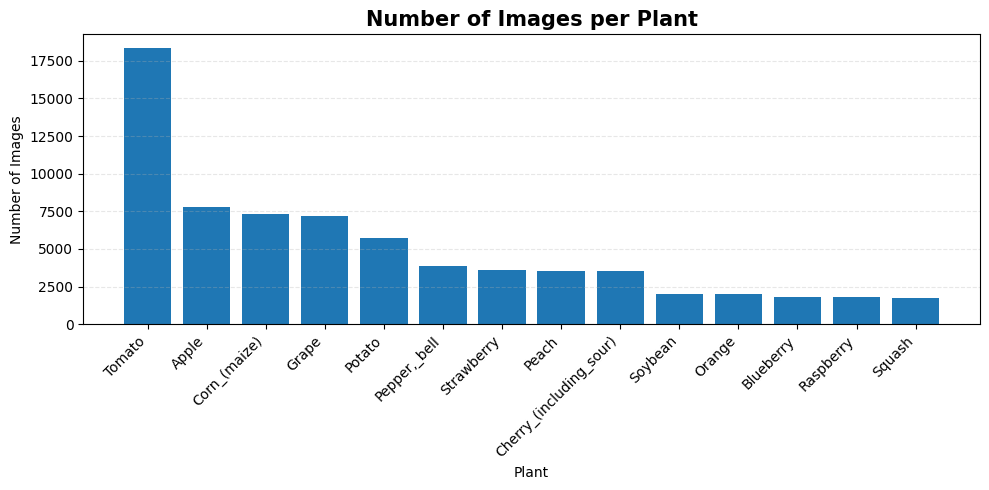

In [ ]:
# @title Images per Plant

images_per_plant = (
    eda_df
    .groupby("Plant")["Number of Images"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    images_per_plant.index,
    images_per_plant.values
)

plt.xlabel("Plant")
plt.ylabel("Number of Images")

plt.title(
    "Number of Images per Plant",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# @title Disease Classes per Plant

import plotly.express as px

classes_per_plant = eda_df.groupby("Plant")["Disease"].nunique().reset_index()
classes_per_plant.columns = ["Plant", "Number of Disease Classes"]

fig = px.bar(
    classes_per_plant.sort_values("Number of Disease Classes"),
    x="Number of Disease Classes",
    y="Plant",
    orientation="h",
    title="Number of Disease Classes per Plant",
    text="Number of Disease Classes"
)

fig.update_traces(
    textposition="outside",
    hovertemplate="<b>%{y}</b><br>Disease Classes: %{x}<extra></extra>"
)

fig.update_layout(
    xaxis_title="Number of Disease Classes",
    yaxis_title="Plant",
    title_x=0.5,
    height=500,
    template="plotly_white"
)

fig.show()

In [ ]:
# @title Healthy vs Diseased — Percentage

import plotly.express as px

eda_df["Health Status"] = eda_df["Disease"].apply(
    lambda x: "Healthy" if x.lower() == "healthy" else "Diseased"
)

health_distribution = (
    eda_df
    .groupby("Health Status")["Number of Images"]
    .sum()
    .reset_index()
)

# Calculate percentage
total_images = health_distribution["Number of Images"].sum()

health_distribution["Percentage"] = (
    health_distribution["Number of Images"] / total_images
) * 100

fig = px.bar(
    health_distribution,
    x="Health Status",
    y="Percentage",
    text="Percentage",
    title="Healthy vs Diseased Images"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside",
    hovertemplate="<b>%{x}</b><br>Percentage: %{y:.2f}%<extra></extra>"
)

fig.update_layout(
    xaxis_title="Health Status",
    yaxis_title="Percentage (%)",
    title_x=0.5,
    height=450,
    template="plotly_white",
    showlegend=False,
    margin=dict(t=80, b=50, l=60, r=30)
)

fig.update_yaxes(
    range=[0, 100],
    ticksuffix="%"
)

fig.show()

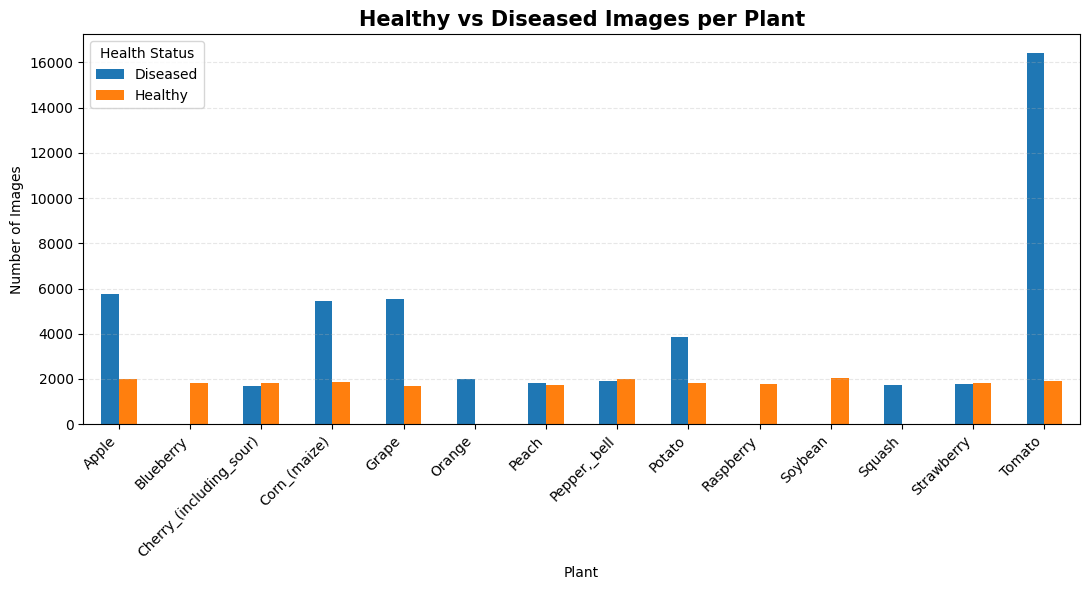

In [ ]:
# @title Healthy vs Diseased per Plant

health_per_plant = (
    eda_df
    .pivot_table(
        index="Plant",
        columns="Health Status",
        values="Number of Images",
        aggfunc="sum",
        fill_value=0
    )
)

health_per_plant.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Plant")
plt.ylabel("Number of Images")

plt.title(
    "Healthy vs Diseased Images per Plant",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# @title Complete Data Cleaning Report — 38 Classes

import os
import hashlib
import pandas as pd
from PIL import Image
from collections import Counter

# ============================================================
# Dataset Paths
# ============================================================

dataset_path = "/content/plant_diseases/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"
train_path = os.path.join(dataset_path, "train")

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# ============================================================
# Get Classes
# ============================================================

classes = sorted([
    folder
    for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

# ============================================================
# Initialize
# ============================================================

empty_classes = []
invalid_files = []
corrupted_images = []
image_sizes = []

class_counts = []

hash_to_files = {}

checked_images = 0

# ============================================================
# Scan Dataset
# ============================================================

for class_name in classes:

    class_path = os.path.join(train_path, class_name)

    all_files = os.listdir(class_path)

    # --------------------------------------------------------
    # Check Empty Classes
    # --------------------------------------------------------

    if len(all_files) == 0:
        empty_classes.append(class_name)

    valid_count = 0

    # --------------------------------------------------------
    # Check Files
    # --------------------------------------------------------

    for file_name in all_files:

        file_path = os.path.join(class_path, file_name)

        if not os.path.isfile(file_path):
            continue

        # Check extension
        if not file_name.lower().endswith(valid_extensions):

            invalid_files.append(file_path)
            continue

        valid_count += 1
        checked_images += 1

        # ----------------------------------------------------
        # Check Corrupted Images
        # ----------------------------------------------------

        try:

            with Image.open(file_path) as img:

                img.verify()

            # Read again to get dimensions
            with Image.open(file_path) as img:

                image_sizes.append(img.size)

        except Exception:

            corrupted_images.append(file_path)
            continue

        # ----------------------------------------------------
        # Calculate Hash for Duplicate Detection
        # ----------------------------------------------------

        try:

            with open(file_path, "rb") as f:
                file_hash = hashlib.md5(f.read()).hexdigest()

            if file_hash not in hash_to_files:
                hash_to_files[file_hash] = []

            hash_to_files[file_hash].append(file_path)

        except Exception:
            pass

    # --------------------------------------------------------
    # Class Count
    # --------------------------------------------------------

    class_counts.append({
        "Class": class_name,
        "Number of Images": valid_count
    })


# ============================================================
# Class Balance
# ============================================================

class_balance = pd.DataFrame(class_counts)

total_valid_images = class_balance["Number of Images"].sum()


# ============================================================
# Duplicate Detection
# ============================================================

duplicate_groups = {
    file_hash: files
    for file_hash, files in hash_to_files.items()
    if len(files) > 1
}

duplicate_images = sum(
    len(files) - 1
    for files in duplicate_groups.values()
)


# ============================================================
# Image Dimensions
# ============================================================

size_counts = Counter(image_sizes)


# ============================================================
# Final Report
# ============================================================

print("=" * 65)
print("🌿 FINAL DATA CLEANING REPORT")
print("=" * 65)

print(f"Classes                 : {len(classes)}")
print(f"Valid images            : {total_valid_images:,}")
print(f"Empty classes           : {len(empty_classes)}")
print(f"Invalid files           : {len(invalid_files)}")
print(f"Corrupted images        : {len(corrupted_images)}")
print(f"Duplicate groups        : {len(duplicate_groups)}")
print(f"Duplicate images        : {duplicate_images}")
print(f"Unique image dimensions : {len(size_counts)}")

print("=" * 65)


# ============================================================
# Detailed Results
# ============================================================

if empty_classes:

    print("\n⚠ Empty Classes:")

    for class_name in empty_classes:
        print(f"  - {class_name}")

else:

    print("✓ No empty classes found.")


if invalid_files:

    print("\n⚠ Invalid Files:")

    for file_path in invalid_files[:10]:
        print(f"  - {file_path}")

    if len(invalid_files) > 10:
        print(f"  ... and {len(invalid_files) - 10} more")

else:

    print("✓ No invalid image files found.")


if corrupted_images:

    print("\n⚠ Corrupted Images:")

    for file_path in corrupted_images[:10]:
        print(f"  - {file_path}")

    if len(corrupted_images) > 10:
        print(f"  ... and {len(corrupted_images) - 10} more")

else:

    print("✓ No corrupted images found.")


# ============================================================
# Duplicate Information
# ============================================================

if duplicate_groups:

    print(
        f"\n⚠ Exact duplicate groups found: "
        f"{len(duplicate_groups)}"
    )

    print(
        f"   Duplicate images: "
        f"{duplicate_images}"
    )

    print(
        "   → Duplicates were detected but not deleted."
    )

else:

    print("✓ No exact duplicate images found.")


# ============================================================
# Image Dimensions
# ============================================================

print("\n" + "=" * 65)
print("IMAGE DIMENSIONS")
print("=" * 65)

for size, count in size_counts.most_common():

    percentage = (count / len(image_sizes)) * 100

    print(
        f"{size} → {count:,} images "
        f"({percentage:.2f}%)"
    )


# ============================================================
# Class Balance Summary
# ============================================================

print("\n" + "=" * 65)
print("CLASS BALANCE")
print("=" * 65)

print(
    f"Minimum images per class : "
    f"{class_balance['Number of Images'].min():,}"
)

print(
    f"Maximum images per class : "
    f"{class_balance['Number of Images'].max():,}"
)

print(
    f"Average images per class : "
    f"{class_balance['Number of Images'].mean():,.2f}"
)


# ============================================================
# Final Status
# ============================================================

print("\n" + "=" * 65)

if (
    len(classes) == 38
    and len(empty_classes) == 0
    and len(invalid_files) == 0
    and len(corrupted_images) == 0
):

    print("✓ DATASET CLEANING CHECK PASSED")

    if duplicate_groups:
        print(
            "⚠ Exact duplicates detected, "
            "but they were retained for further inspection."
        )

else:

    print("⚠ DATASET NEEDS FURTHER INSPECTION")

print("=" * 65)

🌿 FINAL DATA CLEANING REPORT
Classes                 : 38
Valid images            : 70,295
Empty classes           : 0
Invalid files           : 0
Corrupted images        : 0
Duplicate groups        : 18
Duplicate images        : 18
Unique image dimensions : 1
✓ No empty classes found.
✓ No invalid image files found.
✓ No corrupted images found.

⚠ Exact duplicate groups found: 18
   Duplicate images: 18
   → Duplicates were detected but not deleted.

IMAGE DIMENSIONS
(256, 256) → 70,295 images (100.00%)

CLASS BALANCE
Minimum images per class : 1,642
Maximum images per class : 2,022
Average images per class : 1,849.87

✓ DATASET CLEANING CHECK PASSED
⚠ Exact duplicates detected, but they were retained for further inspection.


In [ ]:
# @title Preprocessing

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 56251 images belonging to 38 classes.
Found 14044 images belonging to 38 classes.


In [ ]:
# @title Build CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(38, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# @title Compile Model

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# @title Train CNN

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "plant_disease_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 91s 49ms/step - accuracy: 0.4335 - loss: 1.9522 - val_accuracy: 0.7574 - val_loss: 0.8072
Epoch 2/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.6982 - loss: 0.9781 - val_accuracy: 0.8570 - val_loss: 0.4707
Epoch 3/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.7763 - loss: 0.7097 - val_accuracy: 0.8651 - val_loss: 0.4075
Epoch 4/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 85s 48ms/step - accuracy: 0.8199 - loss: 0.5610 - val_accuracy: 0.8973 - val_loss: 0.3182
Epoch 5/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - accuracy: 0.8463 - loss: 0.4635 - val_accuracy: 0.9024 - val_loss: 0.2990
Epoch 6/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.8692 - loss: 0.3950 - val_accuracy: 0.9179 - val_loss: 0.2538
Epoch 7/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 89s 51ms/step - accuracy: 0.8834 - loss: 0.3585 - val_accuracy: 0.9238 - val_loss: 0.2292
Epoch 8/15
1758/1758 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.8973 -

In [ ]:
# @title Evaluate Model

test_loss, test_accuracy = model.evaluate(validation_generator)

print(f"Validation Loss     : {test_loss:.4f}")
print(f"Validation Accuracy : {test_accuracy:.4f}")

439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9374 - loss: 0.2018
Validation Loss     : 0.2018
Validation Accuracy : 0.9374


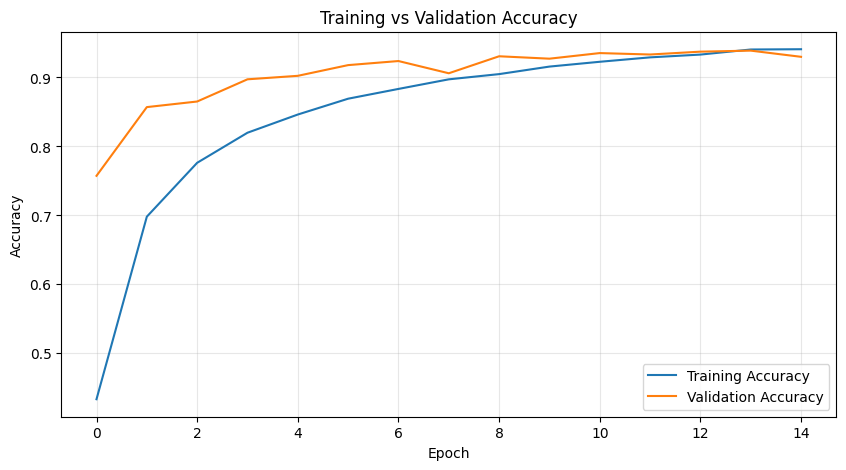

In [ ]:
# @title Training History — Accuracy

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

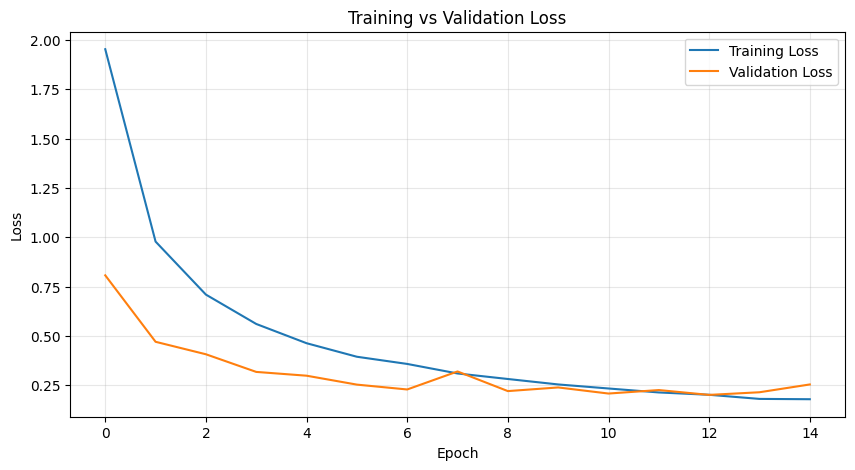

In [ ]:
# @title Training History — Loss

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step


/tmp/ipykernel_2680/3525624842.py:91: UserWarning:

Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.



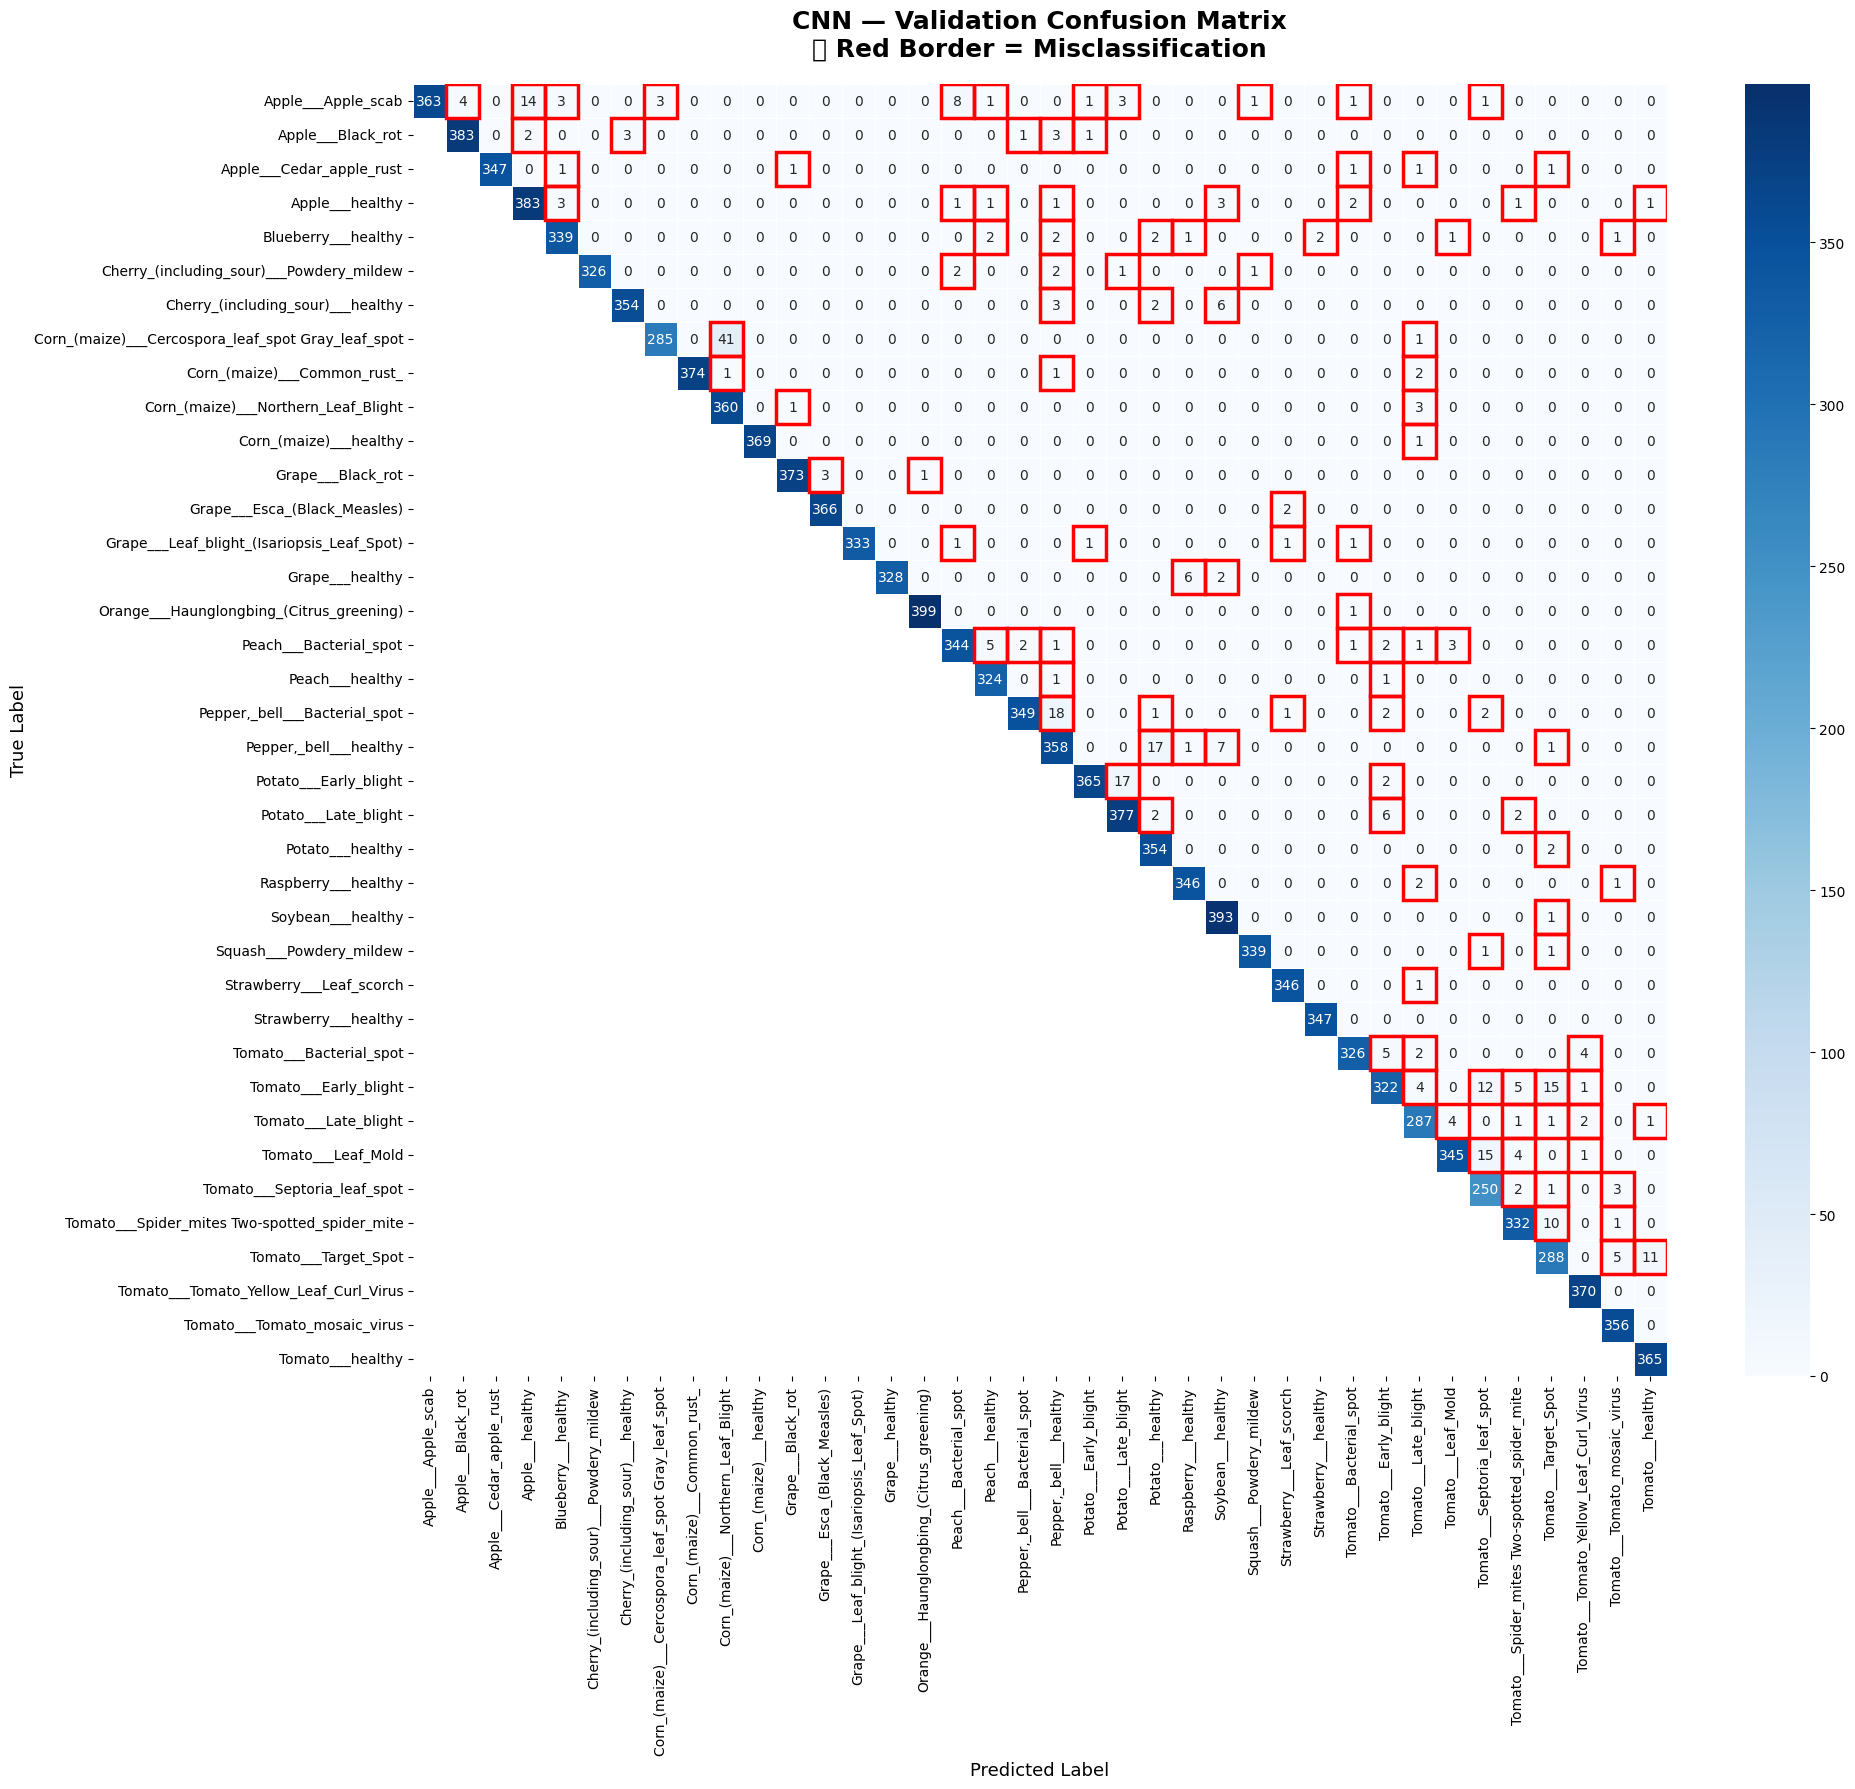

In [ ]:
# @title CNN — Validation Confusion Matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Reset validation generator
validation_generator.reset()

# Predictions
y_pred_prob = model.predict(
    validation_generator,
    verbose=1
)

# Predicted classes
y_pred = np.argmax(y_pred_prob, axis=1)

# True classes
y_true = validation_generator.classes

# Class names
class_names = list(validation_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Create upper triangular mask
mask = np.tril(
    np.ones_like(cm, dtype=bool),
    k=-1
)

# Plot
fig, ax = plt.subplots(figsize=(20, 18))

sns.heatmap(
    cm,
    mask=mask,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    ax=ax
)

# --------------------------------------------------
# 🔴 Highlight misclassified cells with red borders
# --------------------------------------------------

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        # Only mismatches
        if i != j and cm[i, j] > 0:

            # Only cells shown in upper triangle
            if j > i:

                rect = plt.Rectangle(
                    (j, i),
                    1,
                    1,
                    fill=False,
                    edgecolor="red",
                    linewidth=2.5
                )

                ax.add_patch(rect)

# Title
ax.set_title(
    "CNN — Validation Confusion Matrix\n"
    "🔴 Red Border = Misclassification",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# @title Save CNN Model

model_path = "/content/plant_disease_cnn.keras"

model.save(model_path)

print("✓ CNN model saved successfully!")
print(f"Model path: {model_path}")

✓ CNN model saved successfully!
Model path: /content/plant_disease_cnn.keras


## Deployment Preparation — Save Class Mapping

In this step, we save the mapping between the model's output indices and the actual plant disease class names.

The CNN outputs 38 probabilities, one for each class. We need to preserve the exact class mapping so that the Streamlit application can correctly convert the predicted index into a human-readable disease name.

In [ ]:
# @title
import json

# Get class mapping from the training generator
class_indices = train_generator.class_indices

# Reverse mapping:
# Model output index -> class name
idx_to_class = {
    index: class_name
    for class_name, index in class_indices.items()
}

# Save mapping
class_mapping_path = "/content/class_names.json"

with open(class_mapping_path, "w") as f:
    json.dump(idx_to_class, f, indent=4)

print("✓ Class mapping saved successfully!")
print(f"Mapping path: {class_mapping_path}")
print(f"Number of classes: {len(idx_to_class)}")

print("\nExample mappings:")
for index, class_name in list(idx_to_class.items())[:5]:
    print(f"{index} -> {class_name}")

✓ Class mapping saved successfully!
Mapping path: /content/class_names.json
Number of classes: 38

Example mappings:
0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust
3 -> Apple___healthy
4 -> Blueberry___healthy


## Inference Testing

Before building the Streamlit application, we test the saved CNN model on a single image.

The preprocessing used here must exactly match the preprocessing used during training:
- Resize image to 128 × 128
- Convert image to RGB
- Normalize pixel values to the range [0, 1]

This ensures that the model receives input in the same format it learned during training.

In [ ]:
# @title
import json
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import img_to_array

# Load trained model
model = load_model("/content/plant_disease_cnn.keras")

# Load class mapping
with open("/content/class_names.json", "r") as f:
    idx_to_class = {
        int(k): v
        for k, v in json.load(f).items()
    }


def predict_plant_disease(image_path):
    """
    Predict plant disease from a single image.
    """

    # Load and convert image to RGB
    image = Image.open(image_path).convert("RGB")

    # Resize to the same size used during training
    image = image.resize((128, 128))

    # Convert image to numpy array
    image_array = img_to_array(image)

    # Normalize pixel values
    image_array = image_array / 255.0

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Generate prediction
    predictions = model.predict(image_array, verbose=0)[0]

    # Get predicted class
    predicted_index = int(np.argmax(predictions))
    predicted_class = idx_to_class[predicted_index]

    # Get confidence
    confidence = float(predictions[predicted_index])

    return predicted_class, confidence


print("✓ Inference function is ready!")

✓ Inference function is ready!


## Test Inference on a Sample Image

In this step, we test the inference pipeline using a real image from the dataset.

The goal is to verify that the saved model, preprocessing steps, and class mapping work correctly before integrating the model into Streamlit.

In [ ]:
# @title
import os
import random

# Select a random class
class_name = random.choice(list(idx_to_class.values()))

# Training dataset class path
class_path = os.path.join(train_path, class_name)

# Select a random image
image_files = [
    f for f in os.listdir(class_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

image_file = random.choice(image_files)
image_path = os.path.join(class_path, image_file)

# Predict
predicted_class, confidence = predict_plant_disease(image_path)

print("=" * 60)
print("INFERENCE TEST")
print("=" * 60)

print(f"Actual Class     : {class_name}")
print(f"Predicted Class  : {predicted_class}")
print(f"Confidence       : {confidence:.2%}")

print("=" * 60)

INFERENCE TEST
Actual Class     : Tomato___Early_blight
Predicted Class  : Tomato___Early_blight
Confidence       : 99.28%


## Deployment Preparation — Save Class Mapping

The trained CNN predicts a class index rather than the actual disease name.

In this step, we save the mapping between each output index and its corresponding plant disease class. This mapping will later be used by the Streamlit application to convert the model prediction into a human-readable disease name.

In [ ]:
# @title
import json

# Get the class mapping from the training generator
class_indices = train_generator.class_indices

# Reverse the mapping:
# class name -> index
# becomes:
# index -> class name
idx_to_class = {
    index: class_name
    for class_name, index in class_indices.items()
}

# Save the mapping
class_mapping_path = "/content/class_names.json"

with open(class_mapping_path, "w") as f:
    json.dump(idx_to_class, f, indent=4)

print("Class mapping saved successfully!")
print(f"Number of classes: {len(idx_to_class)}")
print(f"Saved to: {class_mapping_path}")

Class mapping saved successfully!
Number of classes: 38
Saved to: /content/class_names.json


In [ ]:
# @title
print(idx_to_class)

{0: 'Apple___Apple_scab', 1: 'Apple___Black_rot', 2: 'Apple___Cedar_apple_rust', 3: 'Apple___healthy', 4: 'Blueberry___healthy', 5: 'Cherry_(including_sour)___Powdery_mildew', 6: 'Cherry_(including_sour)___healthy', 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 8: 'Corn_(maize)___Common_rust_', 9: 'Corn_(maize)___Northern_Leaf_Blight', 10: 'Corn_(maize)___healthy', 11: 'Grape___Black_rot', 12: 'Grape___Esca_(Black_Measles)', 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 14: 'Grape___healthy', 15: 'Orange___Haunglongbing_(Citrus_greening)', 16: 'Peach___Bacterial_spot', 17: 'Peach___healthy', 18: 'Pepper,_bell___Bacterial_spot', 19: 'Pepper,_bell___healthy', 20: 'Potato___Early_blight', 21: 'Potato___Late_blight', 22: 'Potato___healthy', 23: 'Raspberry___healthy', 24: 'Soybean___healthy', 25: 'Squash___Powdery_mildew', 26: 'Strawberry___Leaf_scorch', 27: 'Strawberry___healthy', 28: 'Tomato___Bacterial_spot', 29: 'Tomato___Early_blight', 30: 'Tomato___Late_blight', 31: 'To

## Inference Pipeline

In this step, we create a reusable inference function for predicting the disease of a single plant image.

The preprocessing must be identical to the preprocessing used during training:
- Convert the image to RGB
- Resize it to 128 × 128 pixels
- Normalize pixel values to the range [0, 1]
- Add a batch dimension before passing the image to the CNN

In [ ]:
# @title
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import img_to_array

# Load the trained model
model = load_model("/content/plant_disease_cnn.keras")

# Load class mapping
with open("/content/class_names.json", "r") as f:
    idx_to_class = {
        int(key): value
        for key, value in json.load(f).items()
    }


def predict_plant_disease(image_path):
    """
    Predict the plant disease from a single image.
    """

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize to the same size used during training
    image = image.resize((128, 128))

    # Convert image to NumPy array
    image_array = img_to_array(image)

    # Normalize pixel values
    image_array = image_array / 255.0

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Get predictions
    predictions = model.predict(image_array, verbose=0)[0]

    # Get predicted class index
    predicted_index = int(np.argmax(predictions))

    # Convert index to class name
    predicted_class = idx_to_class[predicted_index]

    # Get confidence
    confidence = float(predictions[predicted_index])

    return predicted_class, confidence

## Improved Inference Pipeline

In [ ]:
# @title
import json
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import img_to_array

# Paths
MODEL_PATH = "/content/plant_disease_cnn.keras"
CLASS_MAPPING_PATH = "/content/class_names.json"

# Image size used during training
IMG_SIZE = (128, 128)

# Load trained model
model = load_model(MODEL_PATH)

# Load class mapping
with open(CLASS_MAPPING_PATH, "r") as f:
    idx_to_class = {
        int(key): value
        for key, value in json.load(f).items()
    }


def predict_plant_disease(image_path, top_k=3):
    """
    Predict the top-k plant disease classes for a single image.
    """

    # Load image and convert to RGB
    image = Image.open(image_path).convert("RGB")

    # Resize to the same size used during training
    image = image.resize(IMG_SIZE)

    # Convert image to NumPy array
    image_array = img_to_array(image)

    # Normalize pixel values
    image_array = image_array / 255.0

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Get model predictions
    predictions = model.predict(image_array, verbose=0)[0]

    # Get indices of top-k predictions
    top_indices = np.argsort(predictions)[::-1][:top_k]

    results = []

    for index in top_indices:

        # Get original class name
        class_name = idx_to_class[int(index)]

        # Separate plant name and disease name
        plant, disease = class_name.split("___", 1)

        # Determine health status
        health_status = (
            "Healthy"
            if disease.lower() == "healthy"
            else "Diseased"
        )

        results.append({
            "class_name": class_name,
            "plant": plant,
            "disease": disease,
            "health_status": health_status,
            "confidence": float(predictions[index])
        })

    return results

## Test the Inference Pipeline

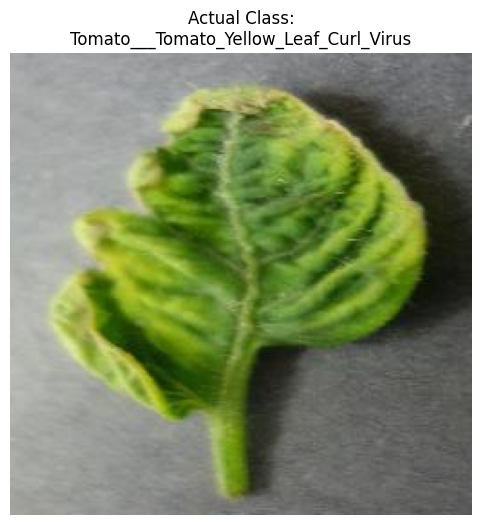

Top 3 Predictions:
--------------------------------------------------
1. Tomato | Tomato_Yellow_Leaf_Curl_Virus | Diseased | 100.00%
2. Orange | Haunglongbing_(Citrus_greening) | Diseased | 0.00%
3. Apple | Cedar_apple_rust | Diseased | 0.00%


In [ ]:
# @title
import os
import random
import matplotlib.pyplot as plt

# Get available validation classes
validation_classes = [
    class_name
    for class_name in os.listdir(valid_path)
    if os.path.isdir(os.path.join(valid_path, class_name))
]

# Select a random class
random_class = random.choice(validation_classes)

# Get images from the selected class
class_path = os.path.join(valid_path, random_class)

image_files = [
    file_name
    for file_name in os.listdir(class_path)
    if file_name.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Select a random image
random_image = random.choice(image_files)
image_path = os.path.join(class_path, random_image)

# Run prediction
results = predict_plant_disease(image_path, top_k=3)

# Display image
image = Image.open(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Actual Class:\n{random_class}")
plt.show()

# Display predictions
print("Top 3 Predictions:")
print("-" * 50)

for i, result in enumerate(results, start=1):
    print(
        f"{i}. {result['plant']} | "
        f"{result['disease']} | "
        f"{result['health_status']} | "
        f"{result['confidence']:.2%}"
    )

## Format Prediction Result

In [ ]:
# @title
def format_prediction_result(result):
    """
    Convert a raw prediction result into a user-friendly format.
    """

    plant = result["plant"].replace("_", " ").title()
    disease = result["disease"].replace("_", " ").title()

    return {
        "plant": plant,
        "disease": disease,
        "health_status": result["health_status"],
        "confidence": result["confidence"]
    }

### Generate User-Friendly Prediction

In [ ]:
# @title
# Get the best prediction
best_prediction = results[0]

# Format the prediction
formatted_result = format_prediction_result(best_prediction)

print("Plant Disease Prediction")
print("=" * 40)

print(f"Plant         : {formatted_result['plant']}")
print(f"Disease       : {formatted_result['disease']}")
print(f"Health Status : {formatted_result['health_status']}")
print(f"Confidence    : {formatted_result['confidence']:.2%}")

Plant Disease Prediction
Plant         : Tomato
Disease       : Tomato Yellow Leaf Curl Virus
Health Status : Diseased
Confidence    : 100.00%


### Final Model Evaluation on Unseen Validation Dataset

In [ ]:
# @title
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create validation data generator
valid_datagen = ImageDataGenerator(
    rescale=1./255
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(f"Validation images: {valid_generator.samples}")
print(f"Validation classes: {valid_generator.num_classes}")

Found 17572 images belonging to 38 classes.
Validation images: 17572
Validation classes: 38


### Evaluate CNN on Unseen Data

In [ ]:
# @title
# Evaluate the trained model on the separate validation dataset

valid_loss, valid_accuracy = model.evaluate(
    valid_generator,
    verbose=1
)

print("=" * 50)
print("FINAL VALIDATION RESULTS")
print("=" * 50)

print(f"Validation Loss     : {valid_loss:.4f}")
print(f"Validation Accuracy : {valid_accuracy:.2%}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.9444 - loss: 0.1822
FINAL VALIDATION RESULTS
Validation Loss     : 0.1822
Validation Accuracy : 94.44%


Classification Report on Unseen Validation Data

In [ ]:
# @title
from sklearn.metrics import classification_report
import numpy as np

# Reset generator
valid_generator.reset()

# Generate predictions
predictions = model.predict(
    valid_generator,
    verbose=1
)

# Convert probabilities to class indices
y_pred = np.argmax(predictions, axis=1)

# True labels
y_true = valid_generator.classes

# Class names
class_names = list(valid_generator.class_indices.keys())

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

550/550 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9500    0.9048    0.9268       504
                                 Apple___Black_rot     0.9735    0.9598    0.9666       497
                          Apple___Cedar_apple_rust     0.9751    0.9795    0.9773       440
                                   Apple___healthy     0.9087    0.9522    0.9300       502
                               Blueberry___healthy     0.9521    0.9626    0.9573       454
          Cherry_(including_sour)___Powdery_mildew     0.9951    0.9739    0.9844       421
                 Cherry_(including_sour)___healthy     0.9701    0.9956    0.9827       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8951    0.8537    0.8739       410
                       Corn_(maize)___Common_rust_     0.9958    0.9832    0.9895       477
               Corn_(maize)___Northe

### Analyze Model Misclassifications

In [ ]:
# @title
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Store misclassifications
misclassifications = []

for true_idx in range(len(class_names)):
    for pred_idx in range(len(class_names)):

        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:

            misclassifications.append({
                "Actual": class_names[true_idx],
                "Predicted": class_names[pred_idx],
                "Errors": cm[true_idx, pred_idx]
            })

# Convert to DataFrame
misclassification_df = pd.DataFrame(
    misclassifications
)

# Sort by number of errors
misclassification_df = misclassification_df.sort_values(
    "Errors",
    ascending=False
).reset_index(drop=True)

print("Top Misclassification Pairs")
print("=" * 70)

display(
    misclassification_df.head(20)
)

Top Misclassification Pairs


,Actual,Predicted,Errors
0,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn_(maize)___Northern_Leaf_Blight,58
1,Tomato___Late_blight,Potato___Late_blight,44
2,Tomato___Target_Spot,Tomato___Spider_mites Two-spotted_spider_mite,43
3,Tomato___Late_blight,Tomato___Early_blight,29
4,Tomato___Septoria_leaf_spot,Tomato___Early_blight,20
5,Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,20
6,Tomato___Tomato_Yellow_Leaf_Curl_Virus,Tomato___Spider_mites Two-spotted_spider_mite,17
7,Apple___Apple_scab,Apple___healthy,15
8,Tomato___Septoria_leaf_spot,"Pepper,_bell___Bacterial_spot",14
9,Grape___Esca_(Black_Measles),Grape___Black_rot,14


### Prepare Deployment Artifacts

In [ ]:
# @title
import os
import shutil

# Create deployment directory
deployment_dir = "/content/deployment"

os.makedirs(deployment_dir, exist_ok=True)

# Copy trained model
shutil.copy(
    "/content/plant_disease_cnn.keras",
    os.path.join(
        deployment_dir,
        "plant_disease_cnn.keras"
    )
)

# Copy class mapping
shutil.copy(
    "/content/class_names.json",
    os.path.join(
        deployment_dir,
        "class_names.json"
    )
)

print("✓ Deployment files prepared")
print()
print("Files:")

for file_name in os.listdir(deployment_dir):
    file_path = os.path.join(
        deployment_dir,
        file_name
    )

    size_mb = os.path.getsize(file_path) / (1024 ** 2)

    print(
        f"- {file_name} "
        f"({size_mb:.2f} MB)"
    )

✓ Deployment files prepared

Files:
- class_names.json (0.00 MB)
- plant_disease_cnn.keras (37.92 MB)


Verify Deployment Files

In [ ]:
# @title
import os

required_files = [
    "plant_disease_cnn.keras",
    "class_names.json"
]

print("Deployment Artifact Check")
print("=" * 50)

for file_name in required_files:

    file_path = os.path.join(
        deployment_dir,
        file_name
    )

    if os.path.exists(file_path):
        print(f"✓ {file_name}")
    else:
        print(f"✗ {file_name}")

Deployment Artifact Check
✓ plant_disease_cnn.keras
✓ class_names.json
